# 06 Christopher Perucho model comparison and residual landscape

This notebook inventories and standardizes the Christopher Perucho/model-comparison and residual-landscape inputs.

## Inventories and Setup

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

ARCHIVE_DIR = PROJECT_ROOT / "archive" / "landscape_figures_analysis"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
CHECKPOINT_DIR = OUTPUT_DIR / "checkpoints"
FIGURE_DIR = PROJECT_ROOT / "figures" / "model_comparison"
CONFIG_PATH = PROJECT_ROOT / "config" / "analysis_config.yml"

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

with open(CONFIG_PATH, "r") as f:
    config = yaml.safe_load(f)

EPSILON = float(config["epsilon"])
MIN_SAMPLE_TOTAL_UMI = int(config["min_sample_total_umi"])

print("Project root:", PROJECT_ROOT)
print("Archive/model-comparison data:", ARCHIVE_DIR)
print("Processed data:", PROCESSED_DIR)
print("Checkpoint output:", CHECKPOINT_DIR)
print("Figure output:", FIGURE_DIR)
print("Config path:", CONFIG_PATH)
print("EPSILON:", EPSILON)
print("Configured MIN_SAMPLE_TOTAL_UMI:", MIN_SAMPLE_TOTAL_UMI)

Project root: /Users/jonathanfelix/Documents/Dissertation_GitHub/rbd-epistasis-landscape
Archive/model-comparison data: /Users/jonathanfelix/Documents/Dissertation_GitHub/rbd-epistasis-landscape/archive/landscape_figures_analysis
Processed data: /Users/jonathanfelix/Documents/Dissertation_GitHub/rbd-epistasis-landscape/data/processed
Checkpoint output: /Users/jonathanfelix/Documents/Dissertation_GitHub/rbd-epistasis-landscape/outputs/checkpoints
Figure output: /Users/jonathanfelix/Documents/Dissertation_GitHub/rbd-epistasis-landscape/figures/model_comparison
Config path: /Users/jonathanfelix/Documents/Dissertation_GitHub/rbd-epistasis-landscape/config/analysis_config.yml
EPSILON: 1e-06
Configured MIN_SAMPLE_TOTAL_UMI: 0


In [2]:
candidate_filenames = [
    "Chris_Master_File_linear_regression_comparison_across_species.xlsx",
    "Chris_Regression_Human_Epistasis.xlsx",
    "human_landscape_predicted_ALL.txt",
    "human_with_experimental_landscape_jons_data.xlsx",
    "human_with_residual_landscape_jons_data.xlsx",
    "linear_reg_human.xlsx",
    "predicted_ModelAll_Anchored_human.xlsx",
    "Residual_Landscape.py",
]

candidate_paths = [ARCHIVE_DIR / filename for filename in candidate_filenames]

candidate_inventory = pd.DataFrame([
    {
        "filename": path.name,
        "relative_path": str(path.relative_to(PROJECT_ROOT)) if path.exists() else "",
        "exists": path.exists(),
        "size_bytes": path.stat().st_size if path.exists() else np.nan,
        "suffix": path.suffix,
    }
    for path in candidate_paths
])

candidate_inventory.to_csv(
    CHECKPOINT_DIR / "model_comparison_candidate_input_inventory.csv",
    index=False
)

candidate_inventory

,filename,relative_path,exists,size_bytes,suffix
0,Chris_Master_File_linear_regression_comparison...,archive/landscape_figures_analysis/Chris_Maste...,True,19616,.xlsx
1,Chris_Regression_Human_Epistasis.xlsx,archive/landscape_figures_analysis/Chris_Regre...,True,9861,.xlsx
2,human_landscape_predicted_ALL.txt,archive/landscape_figures_analysis/human_lands...,True,2397,.txt
3,human_with_experimental_landscape_jons_data.xlsx,archive/landscape_figures_analysis/human_with_...,True,74969,.xlsx
4,human_with_residual_landscape_jons_data.xlsx,archive/landscape_figures_analysis/human_with_...,True,64069,.xlsx
5,linear_reg_human.xlsx,archive/landscape_figures_analysis/linear_reg_...,True,79231,.xlsx
6,predicted_ModelAll_Anchored_human.xlsx,archive/landscape_figures_analysis/predicted_M...,True,64997,.xlsx
7,Residual_Landscape.py,archive/landscape_figures_analysis/Residual_La...,True,3048,.py


In [3]:
archive_file_inventory = []

for path in sorted(ARCHIVE_DIR.glob("*")):
    if path.is_file():
        archive_file_inventory.append({
            "filename": path.name,
            "relative_path": str(path.relative_to(PROJECT_ROOT)),
            "size_bytes": path.stat().st_size,
            "suffix": path.suffix,
        })

archive_file_inventory = pd.DataFrame(archive_file_inventory)

archive_file_inventory.to_csv(
    CHECKPOINT_DIR / "model_comparison_archive_file_inventory.csv",
    index=False
)

archive_file_inventory

,filename,relative_path,size_bytes,suffix
0,.DS_Store,archive/landscape_figures_analysis/.DS_Store,6148,
1,Chris_Master_File_linear_regression_comparison...,archive/landscape_figures_analysis/Chris_Maste...,19616,.xlsx
2,Chris_Regression_Human_Epistasis.xlsx,archive/landscape_figures_analysis/Chris_Regre...,9861,.xlsx
3,Gray_Code.py,archive/landscape_figures_analysis/Gray_Code.py,3739,.py
4,Gray_Code.rtf,archive/landscape_figures_analysis/Gray_Code.rtf,196,.rtf
...,...,...,...,...
57,weighted_optimal_path_ddelta.py,archive/landscape_figures_analysis/weighted_op...,7716,.py
58,weighted_optimal_path_ddelta_all_directed_edge...,archive/landscape_figures_analysis/weighted_op...,162975,.csv
59,weighted_optimal_path_ddelta_optimal_path_edge...,archive/landscape_figures_analysis/weighted_op...,1410,.csv
60,weighted_optimal_path_ddelta_optimal_path_node...,archive/landscape_figures_analysis/weighted_op...,105,.txt


In [4]:
excel_inventory_rows = []

for path in candidate_paths:
    if path.exists() and path.suffix.lower() in [".xlsx", ".xls"]:
        xls = pd.ExcelFile(path)
        
        for sheet_name in xls.sheet_names:
            preview = pd.read_excel(path, sheet_name=sheet_name, nrows=5)
            full_df = pd.read_excel(path, sheet_name=sheet_name)
            
            excel_inventory_rows.append({
                "filename": path.name,
                "sheet_name": sheet_name,
                "n_rows": full_df.shape[0],
                "n_cols": full_df.shape[1],
                "columns": "; ".join(map(str, full_df.columns.tolist())),
            })

excel_sheet_inventory = pd.DataFrame(excel_inventory_rows)

excel_sheet_inventory.to_csv(
    CHECKPOINT_DIR / "model_comparison_excel_sheet_inventory.csv",
    index=False
)

excel_sheet_inventory

,filename,sheet_name,n_rows,n_cols,columns
0,Chris_Master_File_linear_regression_comparison...,coefficients_matrix,38,6,feature; feature_type; bat; human; pangolin; r...
1,Chris_Master_File_linear_regression_comparison...,coefficients_long,152,4,feature; coefficient; feature_type; species
2,Chris_Master_File_linear_regression_comparison...,intercepts,1,5,term; bat; human; pangolin; racoondog
3,Chris_Master_File_linear_regression_comparison...,model_summary,7,5,metric; bat; human; pangolin; racoondog
4,Chris_Regression_Human_Epistasis.xlsx,Sheet1,28,2,Feature; Human
5,human_with_experimental_landscape_jons_data.xlsx,Sheet1,256,28,Variant_new; binary; Amino Acids at Mutated Po...
6,human_with_residual_landscape_jons_data.xlsx,Sheet1,256,29,Variant_new; binary; Amino Acids at Mutated Po...
7,linear_reg_human.xlsx,predictions,256,37,Variant_new; binary; Amino Acids at Mutated Po...
8,linear_reg_human.xlsx,coefficients,38,3,feature; coefficient; feature_type
9,linear_reg_human.xlsx,intercept,1,2,term; value


In [5]:
for path in candidate_paths:
    if path.exists() and path.suffix.lower() in [".xlsx", ".xls"]:
        print(f"\n\n==================== {path.name} ====================")
        xls = pd.ExcelFile(path)
        
        for sheet_name in xls.sheet_names:
            df = pd.read_excel(path, sheet_name=sheet_name)
            print(f"\n--- Sheet: {sheet_name} | shape={df.shape} ---")
            print("Columns:")
            print(list(df.columns))
            display(df.head())



==================== Chris_Master_File_linear_regression_comparison_across_species.xlsx ====================

--- Sheet: coefficients_matrix | shape=(38, 6) ---
Columns:
['feature', 'feature_type', 'bat', 'human', 'pangolin', 'racoondog']


,feature,feature_type,bat,human,pangolin,racoondog
0,IC_total,aggregate_structural,-0.079436,-0.053265,-0.067833,-0.072638
1,NIS_total,aggregate_structural,-0.100894,0.078478,0.253269,0.073817
2,int_1_2,pairwise_epistasis,-0.380512,0.108292,-0.121369,-0.097278
3,int_1_3,pairwise_epistasis,-0.308331,0.069693,-0.277003,-0.079282
4,int_1_4,pairwise_epistasis,-0.258671,-0.032769,0.091144,-0.032446



--- Sheet: coefficients_long | shape=(152, 4) ---
Columns:
['feature', 'coefficient', 'feature_type', 'species']


,feature,coefficient,feature_type,species
0,mut_pos_1,-0.112043,main_effect_bit,human
1,mut_pos_2,-0.057772,main_effect_bit,human
2,mut_pos_3,0.091441,main_effect_bit,human
3,mut_pos_4,-0.134144,main_effect_bit,human
4,mut_pos_5,-0.126911,main_effect_bit,human



--- Sheet: intercepts | shape=(1, 5) ---
Columns:
['term', 'bat', 'human', 'pangolin', 'racoondog']


...

,term,value
0,intercept,-0.98658



--- Sheet: model_summary | shape=(7, 2) ---
Columns:
['metric', 'value']


,metric,value
0,R2,0.472221
1,RMSE,0.493933
2,num_samples,256.000000
3,num_features,38.000000
4,ref_variant_new,1.000000




==================== predicted_ModelAll_Anchored_human.xlsx ====================

--- Sheet: Sheet1 | shape=(256, 33) ---
Columns:
['Variant_new', 'binary', 'Amino Acids at Mutated Positions', 'Text File Name', 'File Content', 'File Link', 'sequence', 'Variant_old', 'Variant', 'Protein-protein complex', 'ΔG (kcal mol-1)', 'Kd (M) at ℃', 'ICs charged-charged', 'ICs charged-polar', 'ICs charged-apolar', 'ICs polar-polar', 'ICs polar-apolar', 'ICs apolar-apolar', 'NIS charged', 'NIS apolar', 'Adjusted', 'mut_pos_1', 'mut_pos_2', 'mut_pos_3', 'mut_pos_4', 'mut_pos_5', 'mut_pos_6', 'mut_pos_7', 'mut_pos_8', 'mutation_count', 'ΔΔG', 'Predicted_ΔΔG', 'Predicted_ΔG']


,Variant_new,binary,Amino Acids at Mutated Positions,Text File Name,File Content,File Link,sequence,Variant_old,Variant,Protein-protein complex,...,mut_pos_3,mut_pos_4,mut_pos_5,mut_pos_6,mut_pos_7,mut_pos_8,mutation_count,ΔΔG,Predicted_ΔΔG,Predicted_ΔG
0,1,0,477_S_478_T_484_E_493_Q_496_G_498_Q_501_N_505_Y,variant_1.txt,MFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSS...,variant_1.txt,STEQGQNY,1,1,variant_1_docked,...,0,0,0,0,0,0,0,0.0,0.0245,-10.6055
1,2,10000000,477_N_478_T_484_E_493_Q_496_G_498_Q_501_N_505_Y,variant_129.txt,MFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSS...,variant_129.txt,NTEQGQNY,129,129,variant_129_docked,...,0,0,0,0,0,0,1,0.1,0.0835,-10.5465
2,3,1000000,477_S_478_K_484_E_493_Q_496_G_498_Q_501_N_505_Y,variant_65.txt,MFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSS...,variant_65.txt,SKEQGQNY,65,65,variant_65_docked,...,0,0,0,0,0,0,1,-0.6,-0.5365,-11.1665
3,4,100000,477_S_478_T_484_A_493_Q_496_G_498_Q_501_N_505_Y,variant_33.txt,MFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSS...,variant_33.txt,STAQGQNY,33,33,variant_33_docked,...,1,0,0,0,0,0,1,-0.2,0.1300,-10.5000
4,5,10000,477_S_478_T_484_E_493_R_496_G_498_Q_501_N_505_Y,variant_17.txt,MFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSS...,variant_17.txt,STERGQNY,17,17,variant_17_docked,...,0,1,0,0,0,0,1,-0.9,-1.0210,-11.6510


In [6]:
for path in candidate_paths:
    if path.exists() and path.suffix.lower() in [".txt", ".csv", ".tsv"]:
        print(f"\n\n==================== {path.name} ====================")
        
        # Try common separators.
        for sep_name, sep in [("tab", "\t"), ("comma", ","), ("whitespace", r"\s+")]:
            try:
                df = pd.read_csv(path, sep=sep, engine="python")
                print(f"\n--- Parsed as {sep_name} | shape={df.shape} ---")
                print("Columns:")
                print(list(df.columns))
                display(df.head())
                break
            except Exception as e:
                print(f"Could not parse as {sep_name}: {e}")

    elif path.exists() and path.suffix.lower() == ".py":
        print(f"\n\n==================== {path.name} ====================")
        with open(path, "r", encoding="utf-8") as f:
            lines = f.readlines()
        
        print(f"Number of lines: {len(lines)}")
        print("\nFirst 80 lines:")
        print("".join(lines[:80]))



==================== human_landscape_predicted_ALL.txt ====================

--- Parsed as tab | shape=(55, 1) ---
Columns:
['import pandas as pd']


,import pandas as pd
0,import matplotlib.pyplot as plt
1,from matplotlib.colors import Normalize
2,from matplotlib import cm
3,import numpy as np
4,from scipy.interpolate import griddata




==================== Residual_Landscape.py ====================
Number of lines: 109

First 80 lines:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from mpl_toolkits.mplot3d import Axes3D  # needed for 3D plotting
from scipy.interpolate import griddata   # pip install scipy if needed

# ===========================
# 1. Load data
# ===========================
excel_path = "linear_reg_human.xlsx"
df = pd.read_excel(excel_path)

# ===========================
# 2. Choose fitness metric
# ===========================
# You can change this to "delta_log2fc_pos_minus_neg" if you want that instead
FITNESS_COL = "DeltaG_pred_docking"

if FITNESS_COL not in df.columns:
    raise KeyError(f"{FITNESS_COL} not found! Check column names in the Excel file.")

# ===========================
# 3. Make sure we have binary_8 and map to x,y
# ===========================
if "binary_8" not in df.columns:
    if "binary" not in df.columns:
        raise KeyError("Neither 'binary_8' 

## Canonical input loading and genotype-key checks

This section loads the candidate canonical model-comparison tables and checks whether genotype identifiers align across files.

The goal is to define stable join keys before reproducing residual-landscape and model-comparison figures.

In [7]:
linear_reg_predictions = pd.read_excel(
    ARCHIVE_DIR / "linear_reg_human.xlsx",
    sheet_name="predictions"
)

linear_reg_coefficients = pd.read_excel(
    ARCHIVE_DIR / "linear_reg_human.xlsx",
    sheet_name="coefficients"
)

linear_reg_intercept = pd.read_excel(
    ARCHIVE_DIR / "linear_reg_human.xlsx",
    sheet_name="intercept"
)

linear_reg_model_summary = pd.read_excel(
    ARCHIVE_DIR / "linear_reg_human.xlsx",
    sheet_name="model_summary"
)

human_experimental = pd.read_excel(
    ARCHIVE_DIR / "human_with_experimental_landscape_jons_data.xlsx"
)

human_residual = pd.read_excel(
    ARCHIVE_DIR / "human_with_residual_landscape_jons_data.xlsx"
)

#cross_species_coefficients = pd.read_excel(
#   ARCHIVE_DIR / "Chris_Master_File_linear_regression_comparison_across_species.xlsx",
#    sheet_name="coefficients_long"
#)

human_pairwise_coefficients = pd.read_excel(
    ARCHIVE_DIR / "Chris_Regression_Human_Epistasis.xlsx"
)

print("linear_reg_predictions:", linear_reg_predictions.shape)
print("linear_reg_coefficients:", linear_reg_coefficients.shape)
print("linear_reg_model_summary:", linear_reg_model_summary.shape)
print("human_experimental:", human_experimental.shape)
print("human_residual:", human_residual.shape)
print("human_pairwise_coefficients:", human_pairwise_coefficients.shape)

linear_reg_predictions: (256, 37)
linear_reg_coefficients: (38, 3)
linear_reg_model_summary: (7, 2)
human_experimental: (256, 28)
human_residual: (256, 29)
human_pairwise_coefficients: (28, 2)


In [8]:
def normalize_binary_8(df: pd.DataFrame) -> pd.DataFrame:
    """
    Ensure binary_8 exists and is an 8-character string.
    """
    out = df.copy()

    if "binary_8" in out.columns:
        out["binary_8"] = out["binary_8"].astype(str).str.zfill(8)
    elif "binary" in out.columns:
        out["binary_8"] = out["binary"].astype(str).str.zfill(8)
    else:
        raise KeyError("Expected either 'binary_8' or 'binary' column.")

    return out


linear_reg_predictions = normalize_binary_8(linear_reg_predictions)
human_experimental = normalize_binary_8(human_experimental)
human_residual = normalize_binary_8(human_residual)

key_check = pd.DataFrame([
    {
        "table": "linear_reg_predictions",
        "n_rows": linear_reg_predictions.shape[0],
        "n_unique_Variant_new": linear_reg_predictions["Variant_new"].nunique() if "Variant_new" in linear_reg_predictions.columns else np.nan,
        "n_unique_binary_8": linear_reg_predictions["binary_8"].nunique(),
        "has_wo": "wo" in linear_reg_predictions.columns,
    },
    {
        "table": "human_experimental",
        "n_rows": human_experimental.shape[0],
        "n_unique_Variant_new": human_experimental["Variant_new"].nunique(),
        "n_unique_binary_8": human_experimental["binary_8"].nunique(),
        "has_wo": "wo" in human_experimental.columns,
    },
    {
        "table": "human_residual",
        "n_rows": human_residual.shape[0],
        "n_unique_Variant_new": human_residual["Variant_new"].nunique(),
        "n_unique_binary_8": human_residual["binary_8"].nunique(),
        "has_wo": "wo" in human_residual.columns,
    },
])

key_check.to_csv(
    CHECKPOINT_DIR / "model_comparison_key_check.csv",
    index=False
)

key_check

,table,n_rows,n_unique_Variant_new,n_unique_binary_8,has_wo
0,linear_reg_predictions,256,256,256,False
1,human_experimental,256,256,256,True
2,human_residual,256,256,256,True


In [9]:
key_sets = {
    "linear_reg_predictions": set(linear_reg_predictions["binary_8"]),
    "human_experimental": set(human_experimental["binary_8"]),
    "human_residual": set(human_residual["binary_8"]),
}

overlap_rows = []

for name_a, keys_a in key_sets.items():
    for name_b, keys_b in key_sets.items():
        overlap_rows.append({
            "table_a": name_a,
            "table_b": name_b,
            "n_a": len(keys_a),
            "n_b": len(keys_b),
            "n_overlap": len(keys_a & keys_b),
            "n_a_not_b": len(keys_a - keys_b),
            "n_b_not_a": len(keys_b - keys_a),
        })

key_overlap = pd.DataFrame(overlap_rows)

key_overlap.to_csv(
    CHECKPOINT_DIR / "model_comparison_key_overlap.csv",
    index=False
)

key_overlap

,table_a,table_b,n_a,n_b,n_overlap,n_a_not_b,n_b_not_a
0,linear_reg_predictions,linear_reg_predictions,256,256,256,0,0
1,linear_reg_predictions,human_experimental,256,256,256,0,0
2,linear_reg_predictions,human_residual,256,256,256,0,0
3,human_experimental,linear_reg_predictions,256,256,256,0,0
4,human_experimental,human_experimental,256,256,256,0,0
5,human_experimental,human_residual,256,256,256,0,0
6,human_residual,linear_reg_predictions,256,256,256,0,0
7,human_residual,human_experimental,256,256,256,0,0
8,human_residual,human_residual,256,256,256,0,0


In [10]:
model_comparison_base = (
    human_residual
    .merge(
        linear_reg_predictions[
            [
                "binary_8",
                "DeltaG_docking",
                "DeltaDeltaG",
                "DeltaG_ref_Wuhan_docking",
                "ΔΔG_pred",
                "ΔG_pred_docking",
                "ΔG_pred_experimental",
                "DeltaG_ref_Wuhan_experimental",
            ]
        ],
        on="binary_8",
        how="left",
        suffixes=("", "_linear_reg")
    )
)

model_comparison_base.to_csv(
    CHECKPOINT_DIR / "model_comparison_base_table.csv",
    index=False
)

print("model_comparison_base:", model_comparison_base.shape)
model_comparison_base.head()

model_comparison_base: (256, 36)


,Variant_new,binary,Amino Acids at Mutated Positions,Text File Name,File Content,File Link,sequence,Variant_old,mut_pos_1,mut_pos_2,...,log2fc_pos_pre_lib1,log2fc_pos_pre_lib2,residual_ΔΔG_pred,DeltaG_docking,DeltaDeltaG,DeltaG_ref_Wuhan_docking,ΔΔG_pred,ΔG_pred_docking,ΔG_pred_experimental,DeltaG_ref_Wuhan_experimental
0,1,0,477_S_478_T_484_E_493_Q_496_G_498_Q_501_N_505_Y,variant_1.txt,MFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSS...,variant_1.txt,STEQGQNY,1,0,0,...,0.253572,0.507641,1.020157,-12.3,0.0,-12.3,-0.155212,-12.455212,-11.475212,-11.32
1,2,10000000,477_N_478_T_484_E_493_Q_496_G_498_Q_501_N_505_Y,variant_129.txt,MFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSS...,variant_129.txt,NTEQGQNY,129,1,0,...,0.475417,0.767004,1.194895,-12.2,0.1,-12.3,-0.323659,-12.623659,-11.643659,-11.32
2,3,1000000,477_S_478_K_484_E_493_Q_496_G_498_Q_501_N_505_Y,variant_65.txt,MFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSS...,variant_65.txt,SKEQGQNY,65,0,1,...,1.252536,0.640756,1.165712,-12.9,-0.6,-12.3,-0.404068,-12.704068,-11.724068,-11.32
3,4,100000,477_S_478_T_484_A_493_Q_496_G_498_Q_501_N_505_Y,variant_33.txt,MFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSS...,variant_33.txt,STAQGQNY,33,0,0,...,-0.541598,0.491500,0.153829,-12.5,-0.2,-12.3,-0.125669,-12.425669,-11.445669,-11.32
4,5,10000,477_S_478_T_484_E_493_R_496_G_498_Q_501_N_505_Y,variant_17.txt,MFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSS...,variant_17.txt,STERGQNY,17,0,0,...,0.033419,-0.619604,0.386636,-13.2,-0.9,-12.3,-1.360826,-13.660826,-12.680826,-11.32


## Model-comparison and residual summary checks

This section summarizes the canonical merged model-comparison table and confirms the main experimental, predicted, and residual columns used for downstream figures.

In [11]:
MODEL_COLUMNS = [
    "DeltaG_docking",
    "DeltaDeltaG",
    "ΔΔG_pred",
    "ΔG_pred_docking",
    "ΔG_pred_experimental",
    "residual_ΔΔG_pred",
    "mean_log2fc_pos_pre",
    "mean_log2fc_neg_pre",
    "delta_log2fc_pos_minus_neg",
]

available_model_columns = [
    col for col in MODEL_COLUMNS
    if col in model_comparison_base.columns
]

model_column_summary = (
    model_comparison_base[available_model_columns]
    .describe()
    .T
    .reset_index()
    .rename(columns={"index": "column"})
)

model_column_summary.to_csv(
    CHECKPOINT_DIR / "model_comparison_column_summary.csv",
    index=False
)

model_column_summary

,column,count,mean,std,min,25%,50%,75%,max
0,DeltaG_docking,256.0,-1.241680e+01,0.681227,-14.300000,-12.900000,-12.500000,-12.000000,-10.300000
1,DeltaDeltaG,256.0,-1.167969e-01,0.681227,-2.000000,-0.600000,-0.200000,0.300000,2.000000
2,ΔΔG_pred,256.0,-1.167969e-01,0.468127,-1.966803,-0.434086,-0.123132,0.178862,1.354867
3,ΔG_pred_docking,256.0,-1.241680e+01,0.468127,-14.266803,-12.734086,-12.423132,-12.121138,-10.945133
4,ΔG_pred_experimental,256.0,-1.143680e+01,0.468127,-13.286803,-11.754086,-11.443132,-11.141138,-9.965133
5,residual_ΔΔG_pred,256.0,-1.387779e-17,1.549549,-5.083775,-0.846026,0.399546,1.096096,4.284343
6,mean_log2fc_pos_pre,256.0,-6.545356e-01,1.687340,-6.340007,-1.700528,-0.284493,0.631547,2.540615
7,mean_log2fc_neg_pre,256.0,-1.355286e-01,0.499646,-1.793857,-0.415893,-0.115637,0.150030,1.755794
8,delta_log2fc_pos_minus_neg,256.0,-5.190070e-01,1.557159,-5.750682,-1.345463,-0.124999,0.568482,3.617693


In [12]:
model_comparison_correlations = (
    model_comparison_base[available_model_columns]
    .corr(method="pearson")
)

model_comparison_correlations.to_csv(
    CHECKPOINT_DIR / "model_comparison_main_quantity_correlations.csv"
)

model_comparison_correlations

,DeltaG_docking,DeltaDeltaG,ΔΔG_pred,ΔG_pred_docking,ΔG_pred_experimental,residual_ΔΔG_pred,mean_log2fc_pos_pre,mean_log2fc_neg_pre,delta_log2fc_pos_minus_neg
DeltaG_docking,1.000000,1.000000,6.871831e-01,6.871831e-01,6.871831e-01,2.432367e-02,0.112568,0.093250,0.092058
DeltaDeltaG,1.000000,1.000000,6.871831e-01,6.871831e-01,6.871831e-01,2.432367e-02,0.112568,0.093250,0.092058
ΔΔG_pred,0.687183,0.687183,1.000000e+00,1.000000e+00,1.000000e+00,-3.199330e-17,0.125410,0.115790,0.098741
ΔG_pred_docking,0.687183,0.687183,1.000000e+00,1.000000e+00,1.000000e+00,3.199903e-16,0.125410,0.115790,0.098741
ΔG_pred_experimental,0.687183,0.687183,1.000000e+00,1.000000e+00,1.000000e+00,-2.826170e-16,0.125410,0.115790,0.098741
residual_ΔΔG_pred,0.024324,0.024324,-3.199330e-17,3.199903e-16,-2.826170e-16,1.000000e+00,0.947967,0.100058,0.995113
mean_log2fc_pos_pre,0.112568,0.112568,1.254096e-01,1.254096e-01,1.254096e-01,9.479673e-01,1.000000,0.398553,0.955718
mean_log2fc_neg_pre,0.093250,0.093250,1.157898e-01,1.157898e-01,1.157898e-01,1.000582e-01,0.398553,1.000000,0.111002
delta_log2fc_pos_minus_neg,0.092058,0.092058,9.874056e-02,9.874056e-02,9.874056e-02,9.951132e-01,0.955718,0.111002,1.000000


In [13]:
from scipy.stats import pearsonr

residual_correlation_rows = []

residual_col = "residual_ΔΔG_pred"

for col in available_model_columns:
    if col == residual_col:
        continue

    valid = model_comparison_base[[col, residual_col]].dropna()
    r_value, p_value = pearsonr(valid[col], valid[residual_col])

    residual_correlation_rows.append({
        "x_column": col,
        "y_column": residual_col,
        "n": valid.shape[0],
        "pearson_r": r_value,
        "p_value": p_value,
    })

residual_correlation_summary = pd.DataFrame(residual_correlation_rows)

residual_correlation_summary.to_csv(
    CHECKPOINT_DIR / "residual_correlation_summary.csv",
    index=False
)

residual_correlation_summary

,x_column,y_column,n,pearson_r,p_value
0,DeltaG_docking,residual_ΔΔG_pred,256,2.432367e-02,6.985108e-01
1,DeltaDeltaG,residual_ΔΔG_pred,256,2.432367e-02,6.985108e-01
2,ΔΔG_pred,residual_ΔΔG_pred,256,-3.469447e-18,1.000000e+00
3,ΔG_pred_docking,residual_ΔΔG_pred,256,1.769418e-16,1.000000e+00
4,ΔG_pred_experimental,residual_ΔΔG_pred,256,-4.059253e-16,1.000000e+00
5,mean_log2fc_pos_pre,residual_ΔΔG_pred,256,9.479673e-01,2.924899e-128
6,mean_log2fc_neg_pre,residual_ΔΔG_pred,256,1.000582e-01,1.102420e-01
7,delta_log2fc_pos_minus_neg,residual_ΔΔG_pred,256,9.951132e-01,2.009495e-257


## Experimental landscape versus predicted human model values

This section compares the experimental enrichment-derived landscape metric against Chris's predicted human model values and residuals.

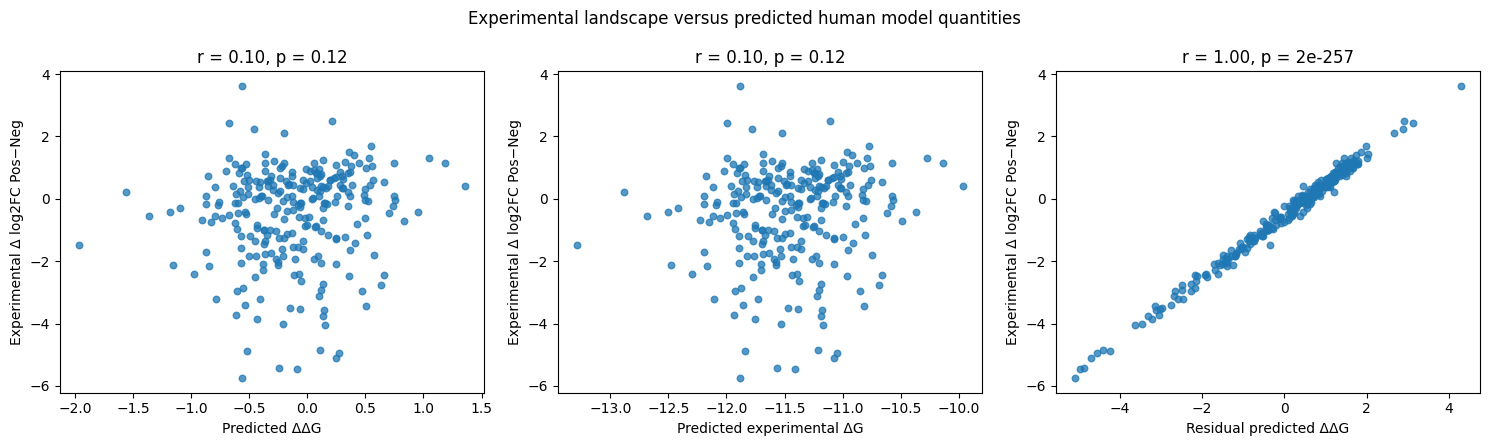

,x_column,y_column,n,pearson_r,p_value
0,ΔΔG_pred,delta_log2fc_pos_minus_neg,256,0.098741,1.150325e-01
1,ΔG_pred_experimental,delta_log2fc_pos_minus_neg,256,0.098741,1.150325e-01
2,residual_ΔΔG_pred,delta_log2fc_pos_minus_neg,256,0.995113,2.009495e-257


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

scatter_specs = [
    ("ΔΔG_pred", "delta_log2fc_pos_minus_neg", "Predicted ΔΔG", "Experimental Δ log2FC Pos−Neg"),
    ("ΔG_pred_experimental", "delta_log2fc_pos_minus_neg", "Predicted experimental ΔG", "Experimental Δ log2FC Pos−Neg"),
    ("residual_ΔΔG_pred", "delta_log2fc_pos_minus_neg", "Residual predicted ΔΔG", "Experimental Δ log2FC Pos−Neg"),
]

scatter_summary_rows = []

for ax, (x_col, y_col, x_label, y_label) in zip(axes, scatter_specs):
    valid = model_comparison_base[[x_col, y_col, "mut_count"]].dropna()

    r_value, p_value = pearsonr(valid[x_col], valid[y_col])

    ax.scatter(
        valid[x_col],
        valid[y_col],
        s=22,
        alpha=0.75
    )

    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.set_title(f"r = {r_value:.2f}, p = {p_value:.2g}")

    scatter_summary_rows.append({
        "x_column": x_col,
        "y_column": y_col,
        "n": valid.shape[0],
        "pearson_r": r_value,
        "p_value": p_value,
    })

fig.suptitle("Experimental landscape versus predicted human model quantities", fontsize=12)
fig.tight_layout()

fig.savefig(
    FIGURE_DIR / "model_vs_experimental_landscape_scatter_panels.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

model_vs_experimental_scatter_summary = pd.DataFrame(scatter_summary_rows)

model_vs_experimental_scatter_summary.to_csv(
    CHECKPOINT_DIR / "model_vs_experimental_scatter_summary.csv",
    index=False
)

model_vs_experimental_scatter_summary

In [15]:
# Confirm how residual_ΔΔG_pred was calculated.

residual_formula_checks = model_comparison_base.copy()

candidate_residual_formulas = {
    "experimental_minus_predicted": (
        residual_formula_checks["delta_log2fc_pos_minus_neg"] -
        residual_formula_checks["ΔΔG_pred"]
    ),
    "predicted_minus_experimental": (
        residual_formula_checks["ΔΔG_pred"] -
        residual_formula_checks["delta_log2fc_pos_minus_neg"]
    ),
    "experimental_plus_predicted": (
        residual_formula_checks["delta_log2fc_pos_minus_neg"] +
        residual_formula_checks["ΔΔG_pred"]
    ),
}

residual_formula_summary_rows = []

for formula_name, formula_values in candidate_residual_formulas.items():
    diff = residual_formula_checks["residual_ΔΔG_pred"] - formula_values
    
    residual_formula_summary_rows.append({
        "formula": formula_name,
        "max_abs_difference": np.max(np.abs(diff)),
        "mean_abs_difference": np.mean(np.abs(diff)),
        "pearson_r_with_existing_residual": pearsonr(
            residual_formula_checks["residual_ΔΔG_pred"],
            formula_values
        )[0],
    })

residual_formula_summary = pd.DataFrame(residual_formula_summary_rows)

residual_formula_summary.to_csv(
    CHECKPOINT_DIR / "residual_formula_check.csv",
    index=False
)

residual_formula_summary

,formula,max_abs_difference,mean_abs_difference,pearson_r_with_existing_residual
0,experimental_minus_predicted,1.390511,0.432132,0.980034
1,predicted_minus_experimental,10.343453,2.352215,-0.980034
2,experimental_plus_predicted,3.093438,0.728913,0.928050


In [16]:
from sklearn.linear_model import LinearRegression

experimental_col = "delta_log2fc_pos_minus_neg"
predicted_col = "ΔΔG_pred"
residual_col = "residual_ΔΔG_pred"

valid = model_comparison_base[
    [experimental_col, predicted_col, residual_col]
].dropna().copy()

X = valid[[predicted_col]].values
y = valid[experimental_col].values

model = LinearRegression()
model.fit(X, y)

valid["fitted_experimental_from_predicted"] = model.predict(X)
valid["recalculated_residual"] = (
    valid[experimental_col] -
    valid["fitted_experimental_from_predicted"]
)

diff = valid[residual_col] - valid["recalculated_residual"]

linear_residual_formula_check = pd.DataFrame([
    {
        "formula": f"{experimental_col} - linear_model({predicted_col})",
        "intercept": model.intercept_,
        "slope": model.coef_[0],
        "r2": model.score(X, y),
        "max_abs_difference": np.max(np.abs(diff)),
        "mean_abs_difference": np.mean(np.abs(diff)),
        "pearson_r_with_existing_residual": pearsonr(
            valid[residual_col],
            valid["recalculated_residual"]
        )[0],
    }
])

linear_residual_formula_check.to_csv(
    CHECKPOINT_DIR / "linear_residual_formula_check.csv",
    index=False
)

linear_residual_formula_check

,formula,intercept,slope,r2,max_abs_difference,mean_abs_difference,pearson_r_with_existing_residual
0,delta_log2fc_pos_minus_neg - linear_model(ΔΔG_...,-0.480646,0.328446,0.00975,1.776357e-15,1.572093e-16,1.0


The stored residual column is reproduced exactly as the residual from a simple linear regression of the experimental enrichment-derived landscape metric, `delta_log2fc_pos_minus_neg`, against Chris's predicted human `ΔΔG_pred`.

Because the fitted model explains very little of the experimental landscape (`R² ≈ 0.0098`), the residual landscape is highly similar to the original experimental metric while representing the component not explained by the predicted human ΔΔG model.

## Residual landscape summary

This section summarizes the residual landscape after removing the component of the experimental enrichment-derived landscape explained by a simple linear model using Chris's predicted human `ΔΔG_pred`.

Because the fitted model explains little of the experimental landscape, these residuals closely track the original experimental metric while explicitly representing model-unexplained variation.

In [17]:
residual_col = "residual_ΔΔG_pred"

top_positive_residuals = (
    model_comparison_base
    .sort_values(residual_col, ascending=False)
    [
        [
            "wo",
            "binary_8",
            "sequence",
            "mut_count",
            "delta_log2fc_pos_minus_neg",
            "ΔΔG_pred",
            residual_col,
        ]
    ]
    .head(15)
)

top_negative_residuals = (
    model_comparison_base
    .sort_values(residual_col, ascending=True)
    [
        [
            "wo",
            "binary_8",
            "sequence",
            "mut_count",
            "delta_log2fc_pos_minus_neg",
            "ΔΔG_pred",
            residual_col,
        ]
    ]
    .head(15)
)

top_positive_residuals.to_csv(
    CHECKPOINT_DIR / "top_positive_residual_genotypes.csv",
    index=False
)

top_negative_residuals.to_csv(
    CHECKPOINT_DIR / "top_negative_residual_genotypes.csv",
    index=False
)

display(top_positive_residuals)
display(top_negative_residuals)

,wo,binary_8,sequence,mut_count,delta_log2fc_pos_minus_neg,ΔΔG_pred,residual_ΔΔG_pred
197,OWWWOOOO,10001111,NTEQSRYH,5,3.617693,-0.566318,4.284343
243,WOOOWOOO,01110111,SKARGRYH,6,2.434041,-0.671618,3.135277
212,WOWWOOOO,01001111,SKEQSRYH,5,2.506626,0.211880,2.917681
161,WWWOWOOO,00010111,STERGRYH,4,2.239190,-0.460586,2.871113
216,WWOOWOOO,00110111,STARGRYH,5,2.123256,-0.197497,2.668769
176,OOWOWOOW,11010110,NKERGRYY,5,1.420158,-0.367295,2.021440
84,WWWOOWOW,00011010,STERSQYY,3,1.312977,-0.679254,2.016721
144,WOWWOOOW,01001110,SKEQSRYY,4,1.690059,0.551562,1.989546
252,OOWOOOOO,11011111,NKERSRYH,7,1.503983,0.357399,1.867242
9,OOWWWWWW,11000000,NKEQGQNY,2,1.222317,-0.289519,1.798054


,wo,binary_8,sequence,mut_count,delta_log2fc_pos_minus_neg,ΔΔG_pred,residual_ΔΔG_pred
85,WWWOOWWO,00011001,STERSQNH,3,-5.750682,-0.567097,-5.083775
200,WOOOOWWO,01111001,SKARSQNH,5,-5.472128,-0.090450,-4.961775
33,WWWWOWWO,00001001,STEQSQNH,2,-5.437080,-0.247869,-4.875023
198,WOOOOOWW,01111100,SKARSRNY,5,-5.097526,0.243968,-4.697011
120,OWWOOWWO,10011001,NTERSQNH,4,-4.948416,0.274336,-4.557875
150,WWOOOWWO,00111001,STARSQNH,4,-4.840056,0.111678,-4.396091
140,WOWOOWWO,01011001,SKERSQNH,4,-4.890336,-0.516712,-4.239979
79,WWOWOWWO,00101001,STAQSQNH,3,-4.053040,0.151934,-3.622297
118,OWWOOOWW,10011100,NTERSRNY,4,-4.004076,-0.209003,-3.454784
219,OOOOOOWW,11111100,NKARSRNY,6,-3.743227,0.134231,-3.306670


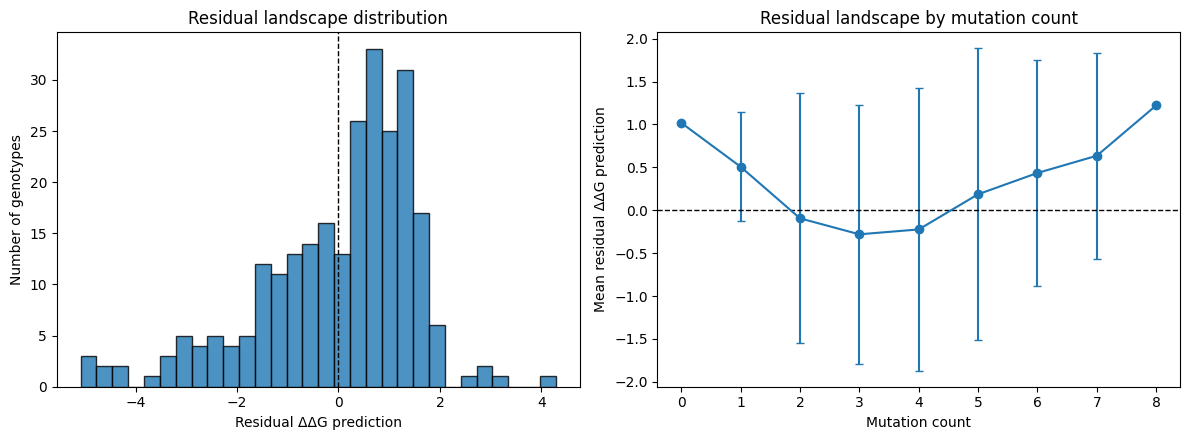

,mut_count,mean_residual,median_residual,sd_residual,n_genotypes
0,0,1.020157,1.020157,NaN,1
1,1,0.507547,0.314054,0.634041,8
2,2,-0.094028,0.166669,1.456119,28
3,3,-0.280529,0.025277,1.512225,56
4,4,-0.223709,0.330805,1.645999,70
5,5,0.186425,0.469201,1.700101,56
6,6,0.434736,0.779026,1.322034,28
7,7,0.635790,1.026058,1.202166,8
8,8,1.222790,1.222790,NaN,1


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].hist(
    model_comparison_base[residual_col].dropna(),
    bins=30,
    edgecolor="black",
    alpha=0.8
)

axes[0].axvline(0, color="black", linestyle="--", linewidth=1)
axes[0].set_xlabel("Residual ΔΔG prediction")
axes[0].set_ylabel("Number of genotypes")
axes[0].set_title("Residual landscape distribution")

residual_by_load = (
    model_comparison_base
    .groupby("mut_count", as_index=False)
    .agg(
        mean_residual=(residual_col, "mean"),
        median_residual=(residual_col, "median"),
        sd_residual=(residual_col, "std"),
        n_genotypes=(residual_col, "size"),
    )
)

axes[1].errorbar(
    residual_by_load["mut_count"],
    residual_by_load["mean_residual"],
    yerr=residual_by_load["sd_residual"],
    marker="o",
    capsize=3,
    linestyle="-"
)

axes[1].axhline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_xlabel("Mutation count")
axes[1].set_ylabel("Mean residual ΔΔG prediction")
axes[1].set_title("Residual landscape by mutation count")

fig.tight_layout()

fig.savefig(
    FIGURE_DIR / "residual_landscape_distribution_and_load.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

residual_by_load.to_csv(
    CHECKPOINT_DIR / "residual_by_mutational_load.csv",
    index=False
)

residual_by_load

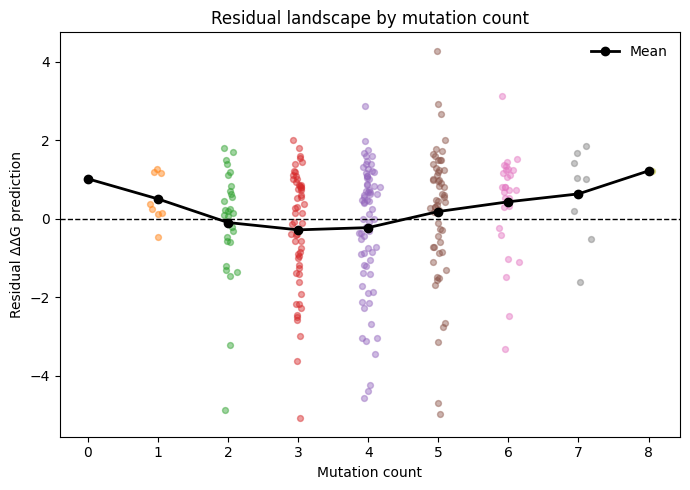

In [19]:
fig, ax = plt.subplots(figsize=(7, 5))

# Jittered genotype-level residuals by mutational load.
rng = np.random.default_rng(42)

for mut_count, group in model_comparison_base.groupby("mut_count"):
    jitter = rng.normal(0, 0.06, size=group.shape[0])
    ax.scatter(
        np.full(group.shape[0], mut_count) + jitter,
        group[residual_col],
        s=18,
        alpha=0.45
    )

# Overlay mean residual by mutational load.
ax.plot(
    residual_by_load["mut_count"],
    residual_by_load["mean_residual"],
    marker="o",
    linewidth=2,
    color="black",
    label="Mean"
)

ax.axhline(0, color="black", linestyle="--", linewidth=1)

ax.set_xlabel("Mutation count")
ax.set_ylabel("Residual ΔΔG prediction")
ax.set_title("Residual landscape by mutation count")
ax.legend(frameon=False)

fig.tight_layout()

fig.savefig(
    FIGURE_DIR / "residual_landscape_by_mutational_load_points.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Residual landscape heatmap

This section maps the 8-bit genotype encoding onto a 16 × 16 coordinate grid. The first four bits define the x-coordinate, and the final four bits define the y-coordinate. The residual landscape is then visualized as a heatmap over all 256 genotypes.

In [20]:
# Map binary_8 genotype strings to 16 × 16 coordinates.

def binary_to_xy(binary_8: str) -> tuple[int, int]:
    binary_8 = str(binary_8).zfill(8)
    x = int(binary_8[:4], 2)
    y = int(binary_8[4:], 2)
    return x, y


residual_landscape_grid = model_comparison_base.copy()

residual_landscape_grid[["x", "y"]] = residual_landscape_grid["binary_8"].apply(
    lambda b: pd.Series(binary_to_xy(b))
)

# Build matrix where rows = y and columns = x.
residual_matrix = (
    residual_landscape_grid
    .pivot(index="y", columns="x", values=residual_col)
    .sort_index(ascending=False)
)

residual_landscape_grid.to_csv(
    CHECKPOINT_DIR / "residual_landscape_xy_table.csv",
    index=False
)

residual_matrix.to_csv(
    CHECKPOINT_DIR / "residual_landscape_16x16_matrix.csv"
)

residual_matrix

x,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
y,,,,,,,,,,,,,,,,
15,0.638083,1.503266,1.249770,1.367489,2.917681,1.163274,1.535568,1.039186,4.284343,1.351436,0.682247,1.415639,1.243840,1.867242,-1.613687,1.222790
14,0.839039,1.171049,1.269940,1.774058,1.989546,1.597652,0.281278,0.812335,1.597252,0.567960,0.435291,0.529049,0.233512,1.057416,0.327828,1.012930
13,0.789200,-1.381559,-0.705119,-1.552729,0.716058,-1.489274,-0.428895,-1.033459,0.627253,-0.721431,-1.298465,-1.478614,0.821804,0.822007,-1.109715,-0.520219
12,-1.197824,-2.587939,-1.178004,-1.872804,-0.407479,-3.033876,-2.678134,-4.697011,-0.128969,-3.454784,-1.202580,-2.754129,0.469002,-0.727326,-0.581787,-3.306670
11,0.756846,0.412455,0.124768,0.625457,1.613797,1.740137,0.311366,-0.409369,0.838192,0.297312,-0.110361,-0.238775,1.233735,1.237506,0.747648,0.200312
10,1.492528,2.016721,0.723479,0.467051,1.445906,0.814340,0.890748,0.966397,1.015857,1.086096,0.492582,1.493271,1.391403,1.408001,0.458498,1.447372
9,-4.875023,-5.083775,-3.622297,-4.396091,-2.492137,-4.239979,-3.025248,-4.961775,-1.388377,-4.557875,-1.897765,-2.645576,-0.857952,-1.496808,-3.132557,-2.479133
8,0.241471,-3.220266,-0.568865,-2.977331,-0.204908,-1.920555,0.141965,-3.120733,0.192429,-2.275528,-0.944593,-0.839734,0.613276,-1.408782,-0.363760,-1.676297
7,0.946650,2.871113,1.217310,2.668769,1.760312,1.648835,1.010963,3.135277,1.322309,1.504451,0.352537,1.260916,1.127900,1.108367,0.810404,1.684921


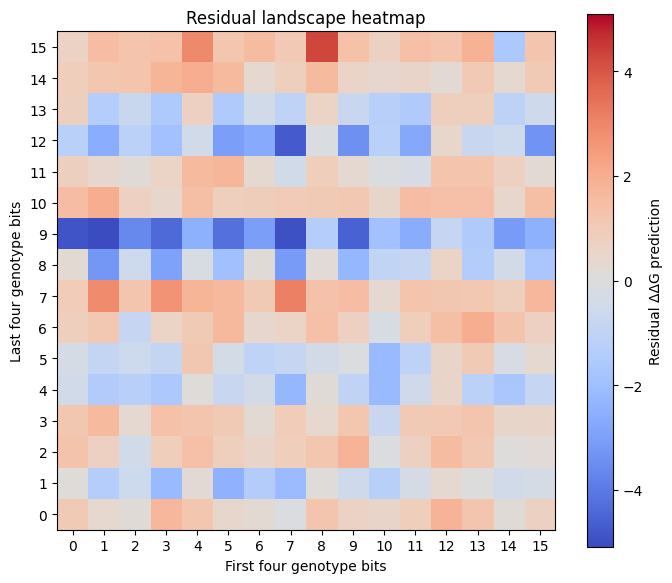

In [21]:
fig, ax = plt.subplots(figsize=(7, 6))

limit = np.nanmax(np.abs(residual_matrix.values))

im = ax.imshow(
    residual_matrix.values,
    cmap="coolwarm",
    vmin=-limit,
    vmax=limit,
    origin="upper"
)

ax.set_xticks(range(16))
ax.set_yticks(range(16))
ax.set_xticklabels(residual_matrix.columns)
ax.set_yticklabels(residual_matrix.index)

ax.set_xlabel("First four genotype bits")
ax.set_ylabel("Last four genotype bits")
ax.set_title("Residual landscape heatmap")

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Residual ΔΔG prediction")

fig.tight_layout()

fig.savefig(
    FIGURE_DIR / "residual_landscape_16x16_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Human model pairwise epistasis comparison

This section compares Chris's human-model pairwise interaction coefficients against the experimental pairwise epistasis summaries generated in notebook 05.

Chris's pairwise terms are encoded as `int_i_j`, where indices correspond to the eight design sites. These are mapped back to residue-position pairs and compared against the cross-library experimental median pairwise epistasis estimates.

In [22]:
PAIRWISE_SUMMARY_PATH = CHECKPOINT_DIR / "pairwise_epistasis_summary_by_pair_library.csv"

experimental_pairwise_summary = pd.read_csv(PAIRWISE_SUMMARY_PATH)

print("experimental_pairwise_summary:", experimental_pairwise_summary.shape)
experimental_pairwise_summary.head()

experimental_pairwise_summary: (84, 9)


,library_id,residue_pair,mean_epsilon,median_epsilon,sd_epsilon,mean_abs_epsilon,median_abs_epsilon,max_abs_epsilon,n_backgrounds
0,1,477-478,0.292380,0.116780,2.227777,1.673945,1.432260,6.734947,64
1,1,477-484,-0.537754,-0.816608,2.129409,1.799958,1.600681,6.723764,64
2,1,477-493,0.487628,0.525392,2.347925,1.838291,1.399003,5.745340,64
3,1,477-496,0.299587,0.349610,2.233081,1.772158,1.486637,5.496868,64
4,1,477-498,-0.504122,-0.325924,2.353139,1.760879,1.333022,7.409489,64


In [23]:
SITE_LABELS = ["477", "478", "484", "493", "496", "498", "501", "505"]

def feature_to_residue_pair(feature: str) -> str:
    """
    Convert Chris feature names like int_1_2 to residue-pair labels like 477-478.
    """
    parts = feature.replace("int_", "").split("_")
    i, j = [int(p) for p in parts]
    return f"{SITE_LABELS[i - 1]}-{SITE_LABELS[j - 1]}"


human_pairwise_model = human_pairwise_coefficients.copy()
human_pairwise_model["residue_pair"] = human_pairwise_model["Feature"].apply(
    feature_to_residue_pair
)

human_pairwise_model = human_pairwise_model.rename(
    columns={"Human": "human_model_pairwise_coefficient"}
)

human_pairwise_model.to_csv(
    CHECKPOINT_DIR / "human_model_pairwise_coefficients_mapped.csv",
    index=False
)

human_pairwise_model.head()

,Feature,human_model_pairwise_coefficient,residue_pair
0,int_1_2,0.108292,477-478
1,int_1_3,0.069693,477-484
2,int_1_4,-0.032769,477-493
3,int_1_5,0.088324,477-496
4,int_1_6,0.172910,477-498


In [24]:
experimental_pairwise_cross_library = (
    experimental_pairwise_summary
    .groupby("residue_pair", as_index=False)
    .agg(
        experimental_mean_median_epsilon=("median_epsilon", "mean"),
        experimental_mean_median_abs_epsilon=("median_abs_epsilon", "mean"),
        experimental_sd_median_epsilon=("median_epsilon", "std"),
        n_libraries=("library_id", "nunique"),
    )
)

pairwise_model_comparison = human_pairwise_model.merge(
    experimental_pairwise_cross_library,
    on="residue_pair",
    how="inner"
)

pairwise_model_comparison.to_csv(
    CHECKPOINT_DIR / "human_model_vs_experimental_pairwise_epistasis.csv",
    index=False
)

print("pairwise_model_comparison:", pairwise_model_comparison.shape)
pairwise_model_comparison.head()

pairwise_model_comparison: (28, 7)


,Feature,human_model_pairwise_coefficient,residue_pair,experimental_mean_median_epsilon,experimental_mean_median_abs_epsilon,experimental_sd_median_epsilon,n_libraries
0,int_1_2,0.108292,477-478,0.063258,1.203676,0.226973,3
1,int_1_3,0.069693,477-484,-0.129864,1.369438,0.601763,3
2,int_1_4,-0.032769,477-493,0.284301,1.392337,0.376586,3
3,int_1_5,0.088324,477-496,-0.024286,1.310730,0.417282,3
4,int_1_6,0.172910,477-498,-0.230455,1.280723,0.082828,3


In [25]:
pairwise_model_comparison_rows = []

comparison_specs = [
    ("human_model_pairwise_coefficient", "experimental_mean_median_epsilon"),
    ("human_model_pairwise_coefficient", "experimental_mean_median_abs_epsilon"),
]

for x_col, y_col in comparison_specs:
    valid = pairwise_model_comparison[[x_col, y_col]].dropna()
    r_value, p_value = pearsonr(valid[x_col], valid[y_col])

    pairwise_model_comparison_rows.append({
        "x_column": x_col,
        "y_column": y_col,
        "n_pairs": valid.shape[0],
        "pearson_r": r_value,
        "p_value": p_value,
    })

pairwise_model_comparison_summary = pd.DataFrame(pairwise_model_comparison_rows)

pairwise_model_comparison_summary.to_csv(
    CHECKPOINT_DIR / "human_model_vs_experimental_pairwise_epistasis_summary.csv",
    index=False
)

pairwise_model_comparison_summary

,x_column,y_column,n_pairs,pearson_r,p_value
0,human_model_pairwise_coefficient,experimental_mean_median_epsilon,28,-0.029936,0.879804
1,human_model_pairwise_coefficient,experimental_mean_median_abs_epsilon,28,-0.273762,0.158639


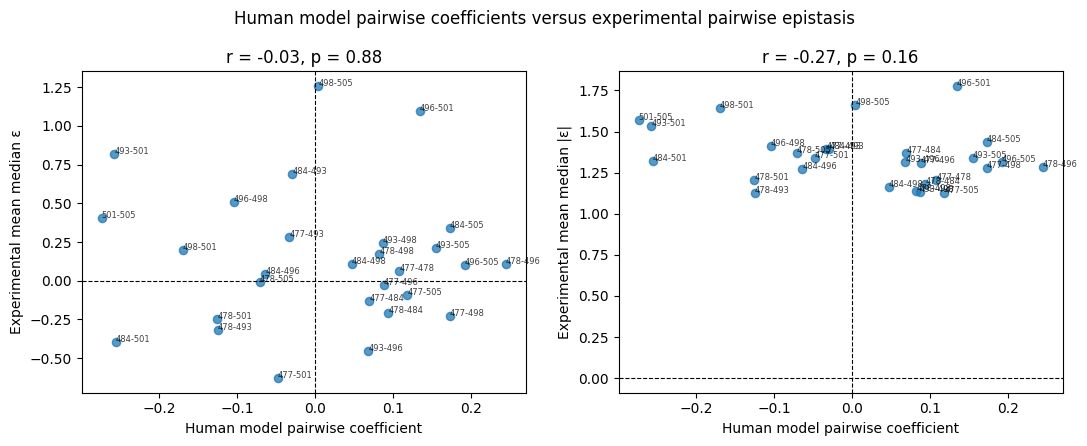

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

scatter_specs = [
    (
        "human_model_pairwise_coefficient",
        "experimental_mean_median_epsilon",
        "Human model pairwise coefficient",
        "Experimental mean median ε"
    ),
    (
        "human_model_pairwise_coefficient",
        "experimental_mean_median_abs_epsilon",
        "Human model pairwise coefficient",
        "Experimental mean median |ε|"
    ),
]

for ax, (x_col, y_col, x_label, y_label) in zip(axes, scatter_specs):
    valid = pairwise_model_comparison[[x_col, y_col, "residue_pair"]].dropna()
    r_value, p_value = pearsonr(valid[x_col], valid[y_col])

    ax.scatter(
        valid[x_col],
        valid[y_col],
        s=35,
        alpha=0.75
    )

    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.axvline(0, color="black", linewidth=0.8, linestyle="--")

    for _, row in valid.iterrows():
        ax.text(
            row[x_col],
            row[y_col],
            row["residue_pair"],
            fontsize=6,
            alpha=0.75
        )

    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.set_title(f"r = {r_value:.2f}, p = {p_value:.2g}")

fig.suptitle("Human model pairwise coefficients versus experimental pairwise epistasis")
fig.tight_layout()

fig.savefig(
    FIGURE_DIR / "human_model_vs_experimental_pairwise_epistasis.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

The human-model pairwise interaction coefficients do not show a strong relationship with the experimentally inferred pairwise epistasis summaries.

The signed comparison between human-model pairwise coefficients and cross-library experimental median pairwise epistasis is near zero, while the comparison against experimental pairwise epistasis magnitude is also weak. This is consistent with the earlier model-versus-experimental landscape comparison, where predicted human `ΔΔG_pred` explained little of the experimental enrichment-derived landscape.

Given this weak baseline correspondence, cross-species coefficient comparisons are not pursued in this notebook. The cross-species files remain inventoried as archived model context, but they are not treated as validated explanatory inputs for the experimental landscape.

## Output inventory

This section records the checkpoint tables and figures generated by this notebook.

In [27]:
model_comparison_figure_inventory = []

for path in sorted(FIGURE_DIR.glob("*.png")):
    model_comparison_figure_inventory.append({
        "figure_file": path.name,
        "relative_path": str(path.relative_to(PROJECT_ROOT)),
        "size_bytes": path.stat().st_size,
    })

model_comparison_figure_inventory = pd.DataFrame(model_comparison_figure_inventory)

model_comparison_figure_inventory.to_csv(
    CHECKPOINT_DIR / "model_comparison_figure_inventory.csv",
    index=False
)

model_comparison_figure_inventory

,figure_file,relative_path,size_bytes
0,human_model_vs_experimental_pairwise_epistasis...,figures/model_comparison/human_model_vs_experi...,303690
1,model_vs_experimental_landscape_scatter_panels...,figures/model_comparison/model_vs_experimental...,320853
2,residual_landscape_16x16_heatmap.png,figures/model_comparison/residual_landscape_16...,97320
3,residual_landscape_by_mutational_load_points.png,figures/model_comparison/residual_landscape_by...,238389
4,residual_landscape_distribution_and_load.png,figures/model_comparison/residual_landscape_di...,150731


In [28]:
model_comparison_checkpoint_inventory = []

checkpoint_patterns = [
    "model_comparison_*.csv",
    "residual_*.csv",
    "top_*_residual_genotypes.csv",
    "linear_residual_formula_check.csv",
    "human_model_*.csv",
]

for pattern in checkpoint_patterns:
    for path in sorted(CHECKPOINT_DIR.glob(pattern)):
        model_comparison_checkpoint_inventory.append({
            "checkpoint_file": path.name,
            "relative_path": str(path.relative_to(PROJECT_ROOT)),
            "size_bytes": path.stat().st_size,
        })

model_comparison_checkpoint_inventory = (
    pd.DataFrame(model_comparison_checkpoint_inventory)
    .drop_duplicates()
    .sort_values("checkpoint_file")
    .reset_index(drop=True)
)

model_comparison_checkpoint_inventory.to_csv(
    CHECKPOINT_DIR / "model_comparison_checkpoint_inventory.csv",
    index=False
)

model_comparison_checkpoint_inventory

,checkpoint_file,relative_path,size_bytes
0,human_model_pairwise_coefficients_mapped.csv,outputs/checkpoints/human_model_pairwise_coeff...,1058
1,human_model_vs_experimental_pairwise_epistasis...,outputs/checkpoints/human_model_vs_experimenta...,2859
2,human_model_vs_experimental_pairwise_epistasis...,outputs/checkpoints/human_model_vs_experimenta...,267
3,linear_residual_formula_check.csv,outputs/checkpoints/linear_residual_formula_ch...,265
4,model_comparison_archive_file_inventory.csv,outputs/checkpoints/model_comparison_archive_f...,7813
5,model_comparison_base_table.csv,outputs/checkpoints/model_comparison_base_tabl...,426153
6,model_comparison_candidate_input_inventory.csv,outputs/checkpoints/model_comparison_candidate...,1090
7,model_comparison_checkpoint_inventory.csv,outputs/checkpoints/model_comparison_checkpoin...,2192
8,model_comparison_column_summary.csv,outputs/checkpoints/model_comparison_column_su...,1380
9,model_comparison_excel_sheet_inventory.csv,outputs/checkpoints/model_comparison_excel_she...,2920


## Final summary

This notebook reconstructs the Chris human-model comparison and residual-landscape workflow from archived model-comparison files.

Candidate archived files were inventoried, relevant Excel sheets were parsed, and canonical human-model, experimental, and residual tables were aligned across all 256 genotypes using the shared `binary_8` genotype key. The merged comparison table was saved as a reproducible checkpoint.

The notebook confirms that the archived residual column is reproduced exactly as the residual from a simple linear regression of the experimental enrichment-derived landscape metric, `delta_log2fc_pos_minus_neg`, against predicted human `ΔΔG_pred`. The fitted model explains little of the experimental landscape, so the residual landscape closely tracks the experimental metric while representing model-unexplained variation.

Generated outputs include model-versus-experimental scatter plots, residual summary tables, residual distribution plots, residual behavior by mutational load, a 16 × 16 residual landscape heatmap, and a comparison between Chris's human-model pairwise coefficients and experimentally inferred pairwise epistasis.

The human-model pairwise coefficients do not show strong correspondence with the experimental pairwise epistasis summaries, matching the weak relationship observed between predicted human `ΔΔG_pred` and the experimental enrichment landscape. Cross-species coefficient comparisons are therefore left as archived model context rather than pursued as a validated explanatory analysis in this notebook.